# Radios dataset

## Download
We need to download it from [https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw](https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw), as including it in version control would be to expensive.

In [1]:
import os

# Define the expected directories
expected_dirs = [
    'Datasets/NORMAL', 'Datasets/PNEUMONIA'
]

# Check if the dataset structure is already present
all_dirs_exist = all(os.path.isdir(dir) for dir in expected_dirs)

if all_dirs_exist:
    print("✅ Dataset is already in place with the correct structure.")
else:
    print("❌ Dataset structure incomplete. Download it from https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw")

✅ Dataset is already in place with the correct structure.


## Structure

The dataset features only images, it's already split in test, train, and evaluation parts, and file names communicate information on the type of pneumonia. Let's check out what kind of data we're working with.

In [2]:
import os
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
from prettytable import PrettyTable

# Dossiers source
normal_dir = "Datasets/NORMAL"
pneumonia_dir = "Datasets/PNEUMONIA"

# Dossiers cible
base_target_dir = "Datasets"
splits = ["train", "val", "test"]
ratios = {"train": 0.75, "val": 0.15, "test": 0.10}  # Ajustez ici

# Récupérer les images NORMAL
normal_images = glob(os.path.join(normal_dir, "*.*"))
normal_labels = ["NORMAL"] * len(normal_images)

# Récupérer les images PNEUMONIA (regroupées sous "PNEUMONIA")
pneumonia_images = glob(os.path.join(pneumonia_dir, "*.*"))
pneumonia_labels = ["PNEUMONIA"] * len(pneumonia_images)

# Combinez tout
all_images = normal_images + pneumonia_images
all_labels = normal_labels + pneumonia_labels

# Créez les dossiers cibles
for split in splits:
    for cls in ["NORMAL", "PNEUMONIA"]:
        os.makedirs(os.path.join(base_target_dir, split, cls), exist_ok=True)

# Split stratifié train / temp (val+test)
img_train, img_temp, lbl_train, lbl_temp = train_test_split(
    all_images, all_labels, test_size=1 - ratios["train"], stratify=all_labels, random_state=42)

# Split val / test
val_ratio_rel = ratios["val"] / (ratios["val"] + ratios["test"])
img_val, img_test, lbl_val, lbl_test = train_test_split(
    img_temp, lbl_temp, test_size=1 - val_ratio_rel, stratify=lbl_temp, random_state=42)

# Fonction pour copier les images dans les dossiers
def copy_images(imgs, lbls, split):
    for img_path, label in zip(imgs, lbls):
        dest_dir = os.path.join(base_target_dir, split, label)
        shutil.copy2(img_path, os.path.join(dest_dir, os.path.basename(img_path)))

# Copier les images
copy_images(img_train, lbl_train, "train")
copy_images(img_val, lbl_val, "val")
copy_images(img_test, lbl_test, "test")

print("Répartition terminée.\n")

# --- Comptage et affichage avec PrettyTable ---
table = PrettyTable()
table.field_names = ["Set", "NORMAL", "PNEUMONIA", "Total"]

for split in splits:
    normal_count = len(glob(os.path.join(base_target_dir, split, "NORMAL", "*.*")))
    pneumonia_count = len(glob(os.path.join(base_target_dir, split, "PNEUMONIA", "*.*")))
    total = normal_count + pneumonia_count
    table.add_row([split, normal_count, pneumonia_count, total])

print(table)


Répartition terminée.

+-------+--------+-----------+-------+
|  Set  | NORMAL | PNEUMONIA | Total |
+-------+--------+-----------+-------+
| train |  1187  |    3205   |  4392 |
|  val  |  237   |    641    |  878  |
|  test |  159   |    427    |  586  |
+-------+--------+-----------+-------+


In [3]:
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob

# Helper function to display images
def display_images(image_paths, titles, cols=3):
    rows = (len(image_paths) + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i, (img_path, title) in enumerate(zip(image_paths, titles)):
        img = Image.open(img_path).convert('L')  # L = luminance (grayscale)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

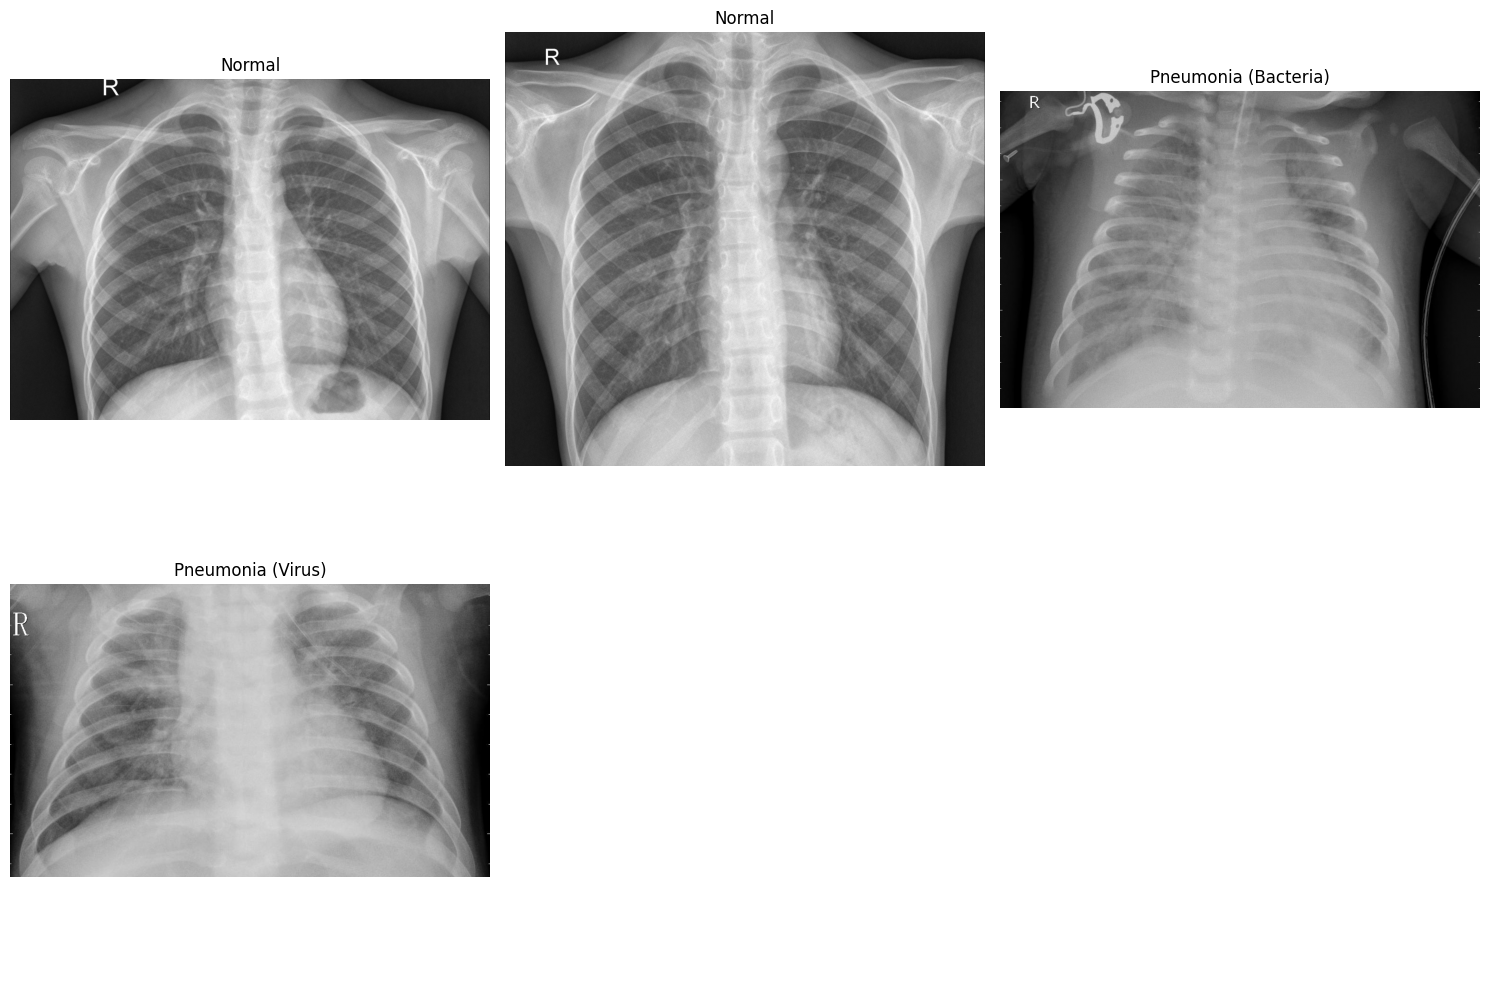

In [4]:
normal_images = glob("Datasets/train/NORMAL/*")[:2]
pneumonia_bacteria_images = glob("Datasets/train/PNEUMONIA/*bacteria*")[:1]
pneumonia_virus_images = glob("Datasets/train/PNEUMONIA/*virus*")[:1]

# Combine the images and titles
image_paths = normal_images + pneumonia_bacteria_images + pneumonia_virus_images
titles = ["Normal"] * len(normal_images) + ["Pneumonia (Bacteria)"] * len(pneumonia_bacteria_images) + ["Pneumonia (Virus)"] * len(pneumonia_virus_images)

# Display the images
display_images(image_paths, titles)

Dimensions some to vary. Let's investigate.

Nombre total d'images analysées : 5856


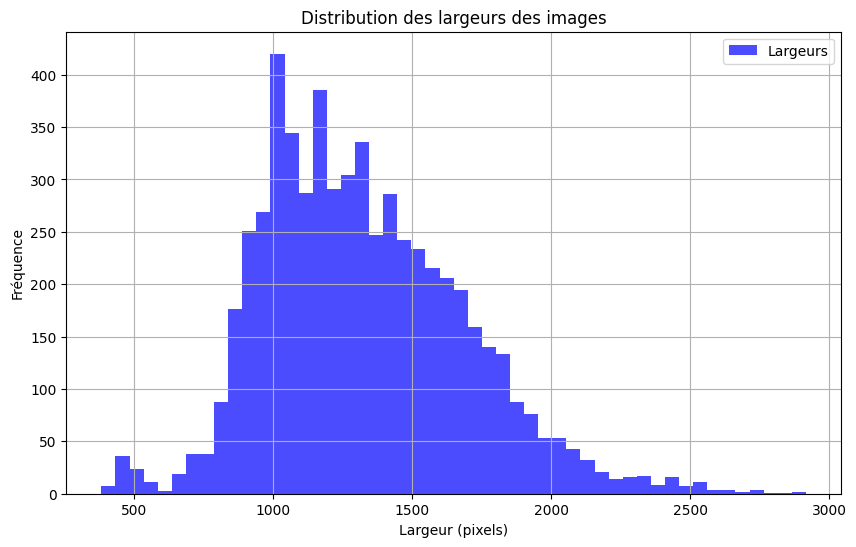

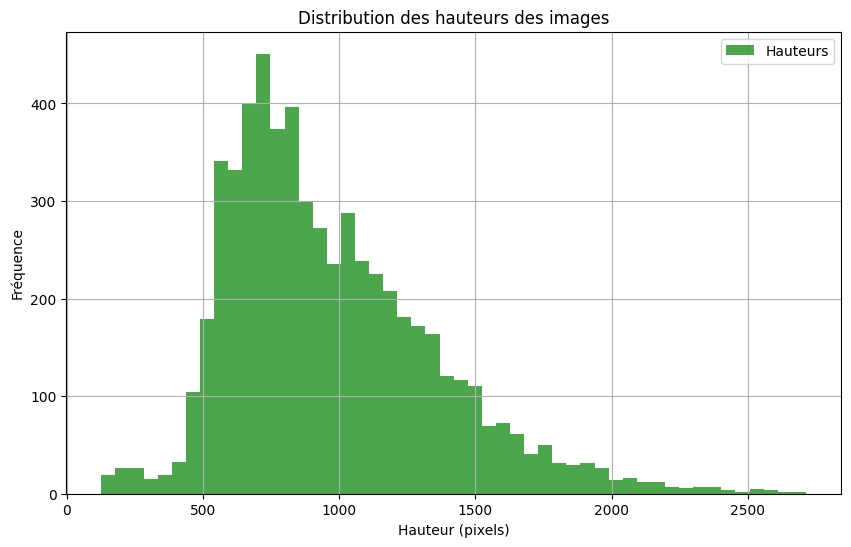

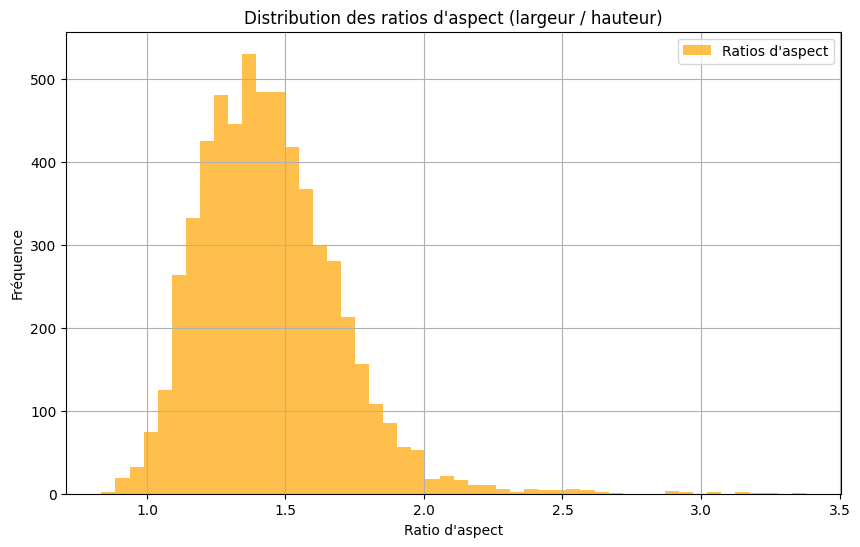

In [5]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

# Récupérer toutes les images .jpeg et .jpg dans NORMAL et PNEUMONIA récursivement
normal_images = glob.glob("Datasets/NORMAL/**/*.jpeg", recursive=True) + glob.glob("Datasets/NORMAL/**/*.jpg", recursive=True)
pneumonia_images = glob.glob("Datasets/PNEUMONIA/**/*.jpeg", recursive=True) + glob.glob("Datasets/PNEUMONIA/**/*.jpg", recursive=True)

all_image_paths = normal_images + pneumonia_images

print(f"Nombre total d'images analysées : {len(all_image_paths)}")

# Analyser les dimensions
widths = []
heights = []

for img_path in all_image_paths:
    with Image.open(img_path) as img:
        widths.append(img.width)
        heights.append(img.height)

# Calculer les ratios d'aspect
aspect_ratios = [w / h for w, h in zip(widths, heights)]

# Histogramme des largeurs
plt.figure(figsize=(10, 6))
plt.hist(widths, bins=50, color='blue', alpha=0.7, label='Largeurs')
plt.title('Distribution des largeurs des images')
plt.xlabel('Largeur (pixels)')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(True)
plt.show()

# Histogramme des hauteurs
plt.figure(figsize=(10, 6))
plt.hist(heights, bins=50, color='green', alpha=0.7, label='Hauteurs')
plt.title('Distribution des hauteurs des images')
plt.xlabel('Hauteur (pixels)')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(True)
plt.show()

# Histogramme des ratios d'aspect
plt.figure(figsize=(10, 6))
plt.hist(aspect_ratios, bins=50, color='orange', alpha=0.7, label='Ratios d\'aspect')
plt.title('Distribution des ratios d\'aspect (largeur / hauteur)')
plt.xlabel('Ratio d\'aspect')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(True)
plt.show()


We can see that image sizes vary widely, and we might need to remove some items from the dataset before moving on, as well as resizing all the images to a smaller dimension.

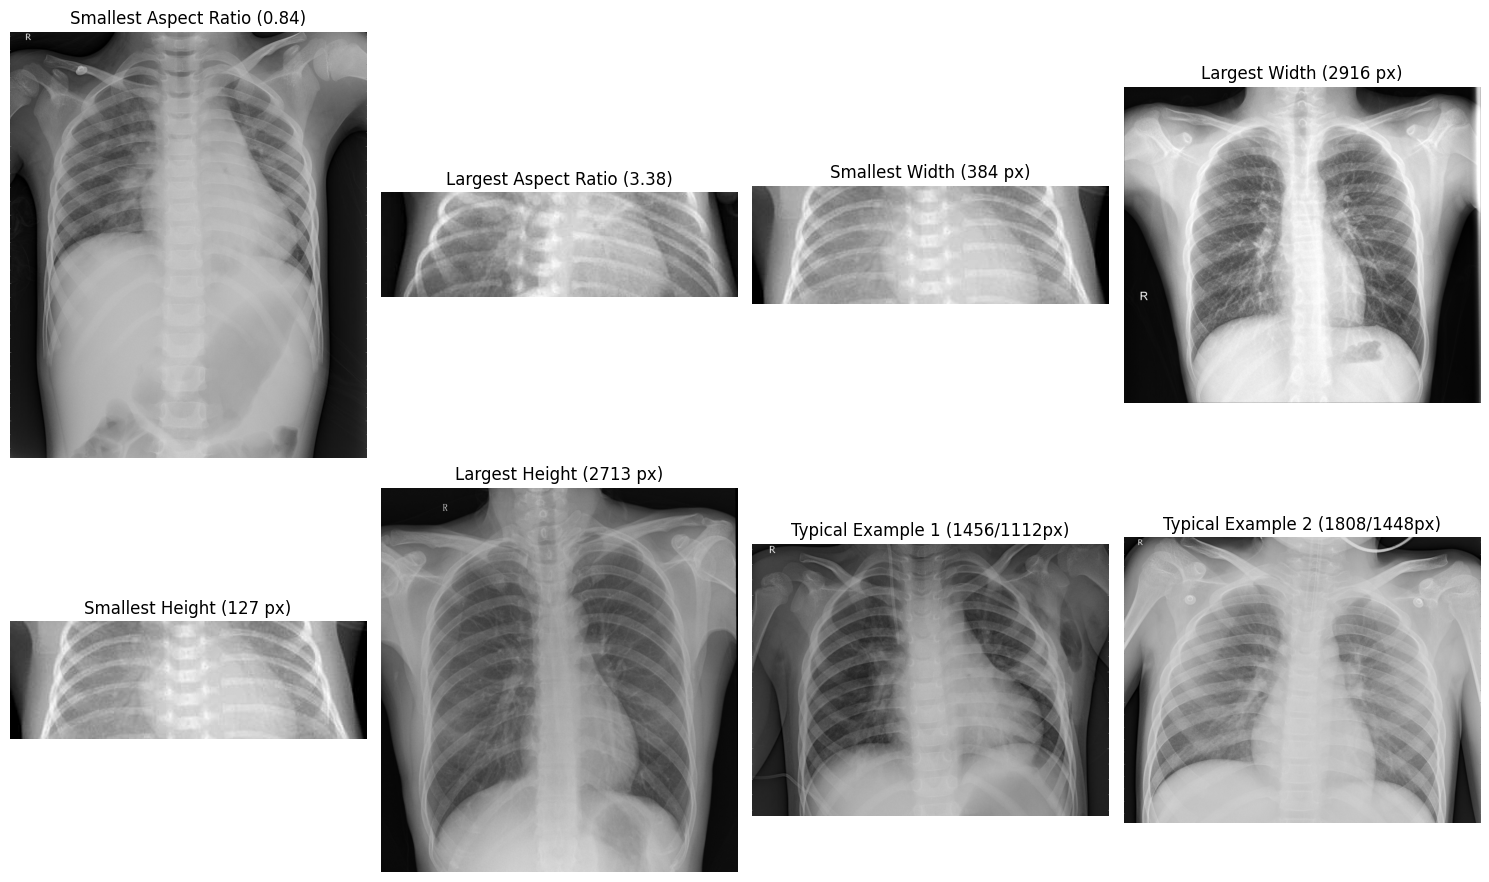

In [6]:
# Find indices of images with the smallest and largest widths and heights
max_aspect_ratio_index = aspect_ratios.index(max(aspect_ratios))
min_aspect_ratio_index = aspect_ratios.index(min(aspect_ratios))
min_width_index = widths.index(min(widths))
max_width_index = widths.index(max(widths))
min_height_index = heights.index(min(heights))
max_height_index = heights.index(max(heights))

# Select a couple of "normal" examples (middle aspect ratios)
normal_example_indices = [len(aspect_ratios) // 3, 2 * len(aspect_ratios) // 3]

# Get the corresponding image paths and titles
extreme_image_paths = [
    all_image_paths[min_aspect_ratio_index],
    all_image_paths[max_aspect_ratio_index],
    all_image_paths[min_width_index],
    all_image_paths[max_width_index],
    all_image_paths[min_height_index],
    all_image_paths[max_height_index],
    all_image_paths[normal_example_indices[0]],
    all_image_paths[normal_example_indices[1]],
]
extreme_titles = [
    f"Smallest Aspect Ratio ({min(aspect_ratios):.2f})",
    f"Largest Aspect Ratio ({max(aspect_ratios):.2f})",
    f"Smallest Width ({min(widths)} px)",
    f"Largest Width ({max(widths)} px)",
    f"Smallest Height ({min(heights)} px)",
    f"Largest Height ({max(heights)} px)",
    f"Typical Example 1 ({widths[normal_example_indices[0]]}/{heights[normal_example_indices[0]]}px)",
    f"Typical Example 2 ({widths[normal_example_indices[1]]}/{heights[normal_example_indices[1]]}px)",
]

# Display the images in an expressive layout
display_images(extreme_image_paths, extreme_titles, cols=4)

Dataset processing to resize usable images to (1024, 1024)

In [2]:
from PIL import Image
import os
from tqdm import tqdm
import numpy as np
import cv2
import shutil
from sklearn.metrics import mutual_info_score
import random

def calculate_image_quality_score(img_np):
    """
    Calcule un score de qualité pour une image basé sur plusieurs métriques.
    Plus le score est élevé, meilleure est la qualité de l'image.
    """
    scores = {}
    
    # 1. Variance (contraste) - images avec plus de contraste sont généralement meilleures
    scores['variance'] = np.var(img_np)
    
    # 2. Gradient magnitude (netteté des contours)
    sobelx = cv2.Sobel(img_np, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_np, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
    scores['sharpness'] = np.mean(gradient_magnitude)
    
    # 3. Entropie (richesse de l'information)
    hist, _ = np.histogram(img_np.flatten(), bins=256, range=[0, 256])
    hist = hist / hist.sum()  # normalisation
    hist = hist[hist > 0]  # éviter log(0)
    scores['entropy'] = -np.sum(hist * np.log2(hist))
    
    # 4. Laplacian variance (mesure de netteté)
    laplacian = cv2.Laplacian(img_np, cv2.CV_64F)
    scores['laplacian_var'] = laplacian.var()
    
    # 5. Range dynamique
    scores['dynamic_range'] = np.max(img_np) - np.min(img_np)
    
    # Score composite normalisé (moyenne pondérée)
    # Poids ajustables selon l'importance de chaque métrique
    weights = {
        'variance': 0.2,
        'sharpness': 0.3,
        'entropy': 0.2,
        'laplacian_var': 0.2,
        'dynamic_range': 0.1
    }
    
    # Normalisation des scores (z-score simplifié)
    normalized_scores = {}
    for key, value in scores.items():
        normalized_scores[key] = value
    
    # Score final pondéré
    final_score = sum(weights[key] * normalized_scores[key] for key in weights.keys())
    
    return final_score, scores

def select_best_images(image_paths, target_count, temp_dir="temp_processing"):
    """
    Sélectionne les meilleures images basées sur les scores de qualité.
    """
    if len(image_paths) <= target_count:
        return image_paths
    
    print(f"Évaluation de {len(image_paths)} images pour en sélectionner {target_count}...")
    
    image_scores = []
    
    # Créer un dossier temporaire pour le traitement
    os.makedirs(temp_dir, exist_ok=True)
    
    for img_path in tqdm(image_paths, desc="Calcul des scores de qualité"):
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((1024, 1024), Image.LANCZOS)
            img_np = np.array(img)
            
            # Appliquer un prétraitement léger pour l'évaluation
            img_np = advanced_preprocess(img_np, use_clahe=True, use_bilateral=False, 
                                       use_sobel=False, use_laplacian=False)
            
            score, detailed_scores = calculate_image_quality_score(img_np)
            image_scores.append((img_path, score, detailed_scores))
            
        except Exception as e:
            print(f"Erreur lors de l'évaluation de {img_path}: {e}")
            continue
    
    # Trier par score décroissant et sélectionner les meilleures
    image_scores.sort(key=lambda x: x[1], reverse=True)
    selected_images = [item[0] for item in image_scores[:target_count]]
    
    print(f"✅ {len(selected_images)} meilleures images sélectionnées")
    print(f"Score moyen des images sélectionnées: {np.mean([item[1] for item in image_scores[:target_count]]):.2f}")
    print(f"Score moyen des images rejetées: {np.mean([item[1] for item in image_scores[target_count:]]):.2f}")
    
    # Nettoyer le dossier temporaire
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    
    return selected_images

def advanced_preprocess(
    img_np, 
    use_clahe=True, 
    use_bilateral=True, 
    use_sobel=True, 
    use_laplacian=False,
    sobel_thresh=50,
    laplacian_weight=0.2
):
    # CLAHE (amélioration du contraste local)
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_np = clahe.apply(img_np)
    # Filtre bilatéral (réduction du bruit)
    if use_bilateral:
        img_np = cv2.bilateralFilter(img_np, d=9, sigmaColor=75, sigmaSpace=75)
    # Renforcement des contours (Sobel + masque adaptatif)
    if use_sobel:
        sobelx = cv2.Sobel(img_np, cv2.CV_64F, 1, 0, ksize=5)
        sobely = cv2.Sobel(img_np, cv2.CV_64F, 0, 1, ksize=5)
        sobel = cv2.magnitude(sobelx, sobely)
        sobel = np.uint8(np.clip(sobel, 0, 255))
        # Masque adaptatif pour ne renforcer que les contours nets
        _, mask = cv2.threshold(sobel, sobel_thresh, 255, cv2.THRESH_BINARY)
        img_np = cv2.addWeighted(img_np, 0.9, mask, 0.1, 0)
    # Laplacian (optionnel, pour détails fins)
    if use_laplacian:
        laplacian = cv2.Laplacian(img_np, cv2.CV_64F)
        laplacian = np.uint8(np.clip(np.abs(laplacian), 0, 255))
        img_np = cv2.addWeighted(img_np, 1-laplacian_weight, laplacian, laplacian_weight, 0)
    # Re-normalisation
    img_np = np.uint8(np.clip(img_np, 0, 255))
    return img_np

def enhance_and_balance_dataset(
    source_dir, 
    target_dir, 
    size=(1024, 1024), 
    equalize=False, 
    median_blur_radius=0,
    use_clahe=True, 
    use_bilateral=True, 
    use_sobel=True,
    use_laplacian=False,
    sobel_thresh=50,
    laplacian_weight=0.2,
    balance_strategy="quality"  # "quality" ou "random"
):
    """
    Traite et équilibre le dataset en sélectionnant les meilleures images de bacteria.
    """
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
        print(f"Le dossier '{target_dir}' a été supprimé.")
    os.makedirs(target_dir, exist_ok=True)
    
    # Créer la structure en 3 classes pour chaque split
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(target_dir, split, "normal"), exist_ok=True)
        os.makedirs(os.path.join(target_dir, split, "bacteria"), exist_ok=True)
        os.makedirs(os.path.join(target_dir, split, "virus"), exist_ok=True)
    
    # Dictionnaire pour compter le nombre d'images dans chaque sous-dossier
    image_counts = {
        "train": {"normal": 0, "bacteria": 0, "virus": 0},
        "val": {"normal": 0, "bacteria": 0, "virus": 0},
        "test": {"normal": 0, "bacteria": 0, "virus": 0}
    }
    
    # Parcourir les splits train/val/test
    for split in ["train", "val", "test"]:
        split_source = os.path.join(source_dir, split)
        split_target = os.path.join(target_dir, split)
        if not os.path.exists(split_source):
            print(f"⚠️ Le dossier source '{split_source}' n'existe pas, il sera ignoré.")
            continue
        
        # Collecter toutes les images par classe
        all_images = {"normal": [], "bacteria": [], "virus": []}
        
        # Parcourir les classes originales (NORMAL, PNEUMONIA)
        for class_name in os.listdir(split_source):
            class_source = os.path.join(split_source, class_name)
            if not os.path.isdir(class_source):
                continue
                
            files = [f for f in os.listdir(class_source) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for file in files:
                img_path = os.path.join(class_source, file)
                
                # Déterminer la classe cible en fonction du nom de fichier
                if class_name.upper() == "NORMAL":
                    target_class = "normal"
                elif "bacteria" in file.lower():
                    target_class = "bacteria"
                elif "virus" in file.lower():
                    target_class = "virus"
                else:
                    target_class = "bacteria"
                
                all_images[target_class].append((img_path, file))
        
        # Calculer le nombre cible pour équilibrer (moyenne des classes normal et virus)
        target_count_bacteria = int((len(all_images["normal"]) + len(all_images["virus"])) / 2)
        
        print(f"\n📊 {split.upper()} - Images disponibles:")
        print(f"  Normal: {len(all_images['normal'])}")
        print(f"  Bacteria: {len(all_images['bacteria'])}")
        print(f"  Virus: {len(all_images['virus'])}")
        print(f"  Cible bacteria: {target_count_bacteria}")
        
        # Sélectionner les meilleures images de bacteria si nécessaire
        if len(all_images["bacteria"]) > target_count_bacteria:
            if balance_strategy == "quality":
                bacteria_paths = [item[0] for item in all_images["bacteria"]]
                selected_bacteria_paths = select_best_images(bacteria_paths, target_count_bacteria)
                # Reconstituer la liste avec les noms de fichiers
                selected_bacteria = []
                for selected_path in selected_bacteria_paths:
                    for img_path, file in all_images["bacteria"]:
                        if img_path == selected_path:
                            selected_bacteria.append((img_path, file))
                            break
                all_images["bacteria"] = selected_bacteria
            else:  # random
                all_images["bacteria"] = random.sample(all_images["bacteria"], target_count_bacteria)
        
        # Traiter toutes les images sélectionnées
        for target_class, images in all_images.items():
            for img_path, file in tqdm(images, desc=f"Traitement {split}/{target_class}"):
                target_path = os.path.join(split_target, target_class, file)
                
                try:
                    img = Image.open(img_path).convert('L')  # niveaux de gris
                    img = img.resize(size, Image.LANCZOS)
                    img_np = np.array(img)

                    # Traitement avancé
                    img_np = advanced_preprocess(
                        img_np, 
                        use_clahe=use_clahe, 
                        use_bilateral=use_bilateral, 
                        use_sobel=use_sobel,
                        use_laplacian=use_laplacian,
                        sobel_thresh=sobel_thresh,
                        laplacian_weight=laplacian_weight
                    )

                    # Optionnel : égalisation globale ou flou médian 
                    if equalize:
                        img_np = cv2.equalizeHist(img_np)
                    if median_blur_radius > 0:
                        img_np = cv2.medianBlur(img_np, median_blur_radius)

                    img_processed = Image.fromarray(img_np)
                    img_processed.save(target_path)
                    
                    # Mettre à jour le compteur pour la classe cible et le split
                    image_counts[split][target_class] += 1
                except Exception as e:
                    print(f"Erreur sur {img_path} : {e}")
    
    # Afficher le tableau récapitulatif du nombre d'images traitées
    print("\n✅ Tableau récapitulatif du nombre d'images traitées (équilibrées):")
    print("Split\t\tNormal\tBacteria\tVirus")
    for split in ["train", "val", "test"]:
        print(f"{split.capitalize()}\t\t{image_counts[split]['normal']}\t{image_counts[split]['bacteria']}\t{image_counts[split]['virus']}")
    
    return image_counts

# Paramètres
source_dir = "Datasets"  # dossier avec train/val/test/NORMAL/PNEUMONIA
target_dir = "balanced_dataset"
equalize = False  # Désactivé car CLAHE est plus puissant
median_blur_radius = 0  # 0 pour désactiver le flou médian

# Active/désactive les étapes avancées ici :
use_clahe = True
use_bilateral = True
use_sobel = True
use_laplacian = True  # Active Laplacian pour plus de détails

# Stratégie d'équilibrage : "quality" pour sélectionner les meilleures images, "random" pour aléatoire
balance_strategy = "quality"

print("🚀 Début du traitement et équilibrage du dataset...")
final_counts = enhance_and_balance_dataset(
    source_dir, 
    target_dir, 
    equalize=equalize, 
    median_blur_radius=median_blur_radius,
    use_clahe=use_clahe,
    use_bilateral=use_bilateral,
    use_sobel=use_sobel,
    use_laplacian=use_laplacian,
    sobel_thresh=50,
    laplacian_weight=0.2,
    balance_strategy=balance_strategy
)

print(f"\n✅ Toutes les images ont été traitées et équilibrées dans '{target_dir}'.")

# Calculer et afficher les statistiques d'équilibrage
print(f"\n📈 Statistiques d'équilibrage:")
for split in ["train", "val", "test"]:
    total = sum(final_counts[split].values())
    if total > 0:
        normal_pct = (final_counts[split]['normal'] / total) * 100
        bacteria_pct = (final_counts[split]['bacteria'] / total) * 100
        virus_pct = (final_counts[split]['virus'] / total) * 100
        print(f"{split.capitalize()}: Normal {normal_pct:.1f}%, Bacteria {bacteria_pct:.1f}%, Virus {virus_pct:.1f}%")

# Pour visualiser une image traitée
try:
    sample_path = os.path.join(target_dir, "train/normal", os.listdir(os.path.join(target_dir, "train/normal"))[0])
    img = Image.open(sample_path)
    img.show()
    print(f"Image d'exemple affichée: {sample_path}")
except:
    print("Impossible d'afficher l'image d'exemple")

🚀 Début du traitement et équilibrage du dataset...

📊 TRAIN - Images disponibles:
  Normal: 1187
  Bacteria: 2098
  Virus: 1107
  Cible bacteria: 1147
Évaluation de 2098 images pour en sélectionner 1147...


Calcul des scores de qualité: 100%|██████████| 2098/2098 [01:51<00:00, 18.86it/s]


✅ 1147 meilleures images sélectionnées
Score moyen des images sélectionnées: 840.64
Score moyen des images rejetées: 558.55


Traitement train/virus: 100%|██████████| 1107/1107 [01:11<00:00, 15.54it/s]



📊 VAL - Images disponibles:
  Normal: 237
  Bacteria: 412
  Virus: 229
  Cible bacteria: 233
Évaluation de 412 images pour en sélectionner 233...


...


📊 TEST - Images disponibles:
  Normal: 159
  Bacteria: 270
  Virus: 157
  Cible bacteria: 158
Évaluation de 270 images pour en sélectionner 158...


Calcul des scores de qualité: 100%|██████████| 270/270 [00:14<00:00, 18.99it/s]


✅ 158 meilleures images sélectionnées
Score moyen des images sélectionnées: 825.01
Score moyen des images rejetées: 550.51


Traitement test/virus: 100%|██████████| 157/157 [00:09<00:00, 16.23it/s]



✅ Tableau récapitulatif du nombre d'images traitées (équilibrées):
Split		Normal	Bacteria	Virus
Train		1187	1147	1107
Val		237	233	229
Test		159	158	157

✅ Toutes les images ont été traitées et équilibrées dans 'balanced_dataset'.

📈 Statistiques d'équilibrage:
Train: Normal 34.5%, Bacteria 33.3%, Virus 32.2%
Val: Normal 33.9%, Bacteria 33.3%, Virus 32.8%
Test: Normal 33.5%, Bacteria 33.3%, Virus 33.1%
Image d'exemple affichée: balanced_dataset\train/normal\IM-0001-0001.jpeg


Classification tertiaire

In [ ]:
import os
import logging
import cv2
from PIL import Image
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import InterpolationMode
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, f1_score
from torchvision.models import resnet34, ResNet34_Weights
import numpy as np

# --- Configuration et chemins ---
train_dir = 'balanced_dataset/train'  # Changé pour utiliser le dataset équilibré
val_dir = 'balanced_dataset/val'
test_dir = 'balanced_dataset/test'
model_dir = 'models'
batch_size = 32
num_epochs = 80
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Logging ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')



class CLAHETransform(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        img_np = np.array(img)
        if img_np.ndim == 3 and img_np.shape[2] == 3:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        img_clahe = clahe.apply(img_np)
        return Image.fromarray(img_clahe)
    
# --- Dataset personnalisé à 3 classes ---
class ThreeClassImageFolder(Dataset):
    def __init__(self, root, transform=None, bacteria_transform=None):
        self.root = root
        self.transform = transform
        self.bacteria_transform = bacteria_transform
        self.samples = []
        self.classes = ['normal', 'bacteria', 'virus']
        self.class_to_idx = {'normal': 0, 'bacteria': 1, 'virus': 2}
        self._load_samples()

    def _load_samples(self):
        for cls_name in os.listdir(self.root):
            cls_dir = os.path.join(self.root, cls_name)
            if not os.path.isdir(cls_dir):
                continue
            for root_dir, _, fnames in os.walk(cls_dir):
                for fname in fnames:
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        path = os.path.join(root_dir, fname)
                        if cls_name.lower() == 'normal':
                            label = 0
                        elif cls_name.lower() == 'bacteria':
                            label = 1
                        elif cls_name.lower() == 'virus':
                            label = 2
                        self.samples.append((path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.02):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

    def __repr__(self):
        return self.__class__.__name__ + f'(mean={self.mean}, std={self.std})'
# --- Transformations ---
train_transforms = transforms.Compose([
    transforms.Resize(400, interpolation=InterpolationMode.BICUBIC),
    CLAHETransform(),
    transforms.RandomRotation(15, interpolation=InterpolationMode.BILINEAR),
    transforms.RandomAffine(degrees=0, translate=(0.10, 0.10), scale=(0.90, 1.10), shear=0.10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.03),
    transforms.RandomHorizontalFlip(),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.01),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

bacteria_transforms = transforms.Compose([
    transforms.Resize(400, interpolation=InterpolationMode.BICUBIC),
    CLAHETransform(),
    transforms.RandomRotation(30, interpolation=InterpolationMode.BILINEAR),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15), shear=0.15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.RandomHorizontalFlip(),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.02),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(400, interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])
# --- Chargement des datasets ---
train_dataset = ThreeClassImageFolder(train_dir, transform=train_transforms)
val_dataset = ThreeClassImageFolder(val_dir, transform=val_test_transforms)
test_dataset = ThreeClassImageFolder(test_dir, transform=val_test_transforms)

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# --- Modèle ---
class ResNet34WithDropout(nn.Module):
    def __init__(self, base_model, num_classes, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(base_model.fc.in_features, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


base_model = resnet34(weights=ResNet34_Weights.DEFAULT)
base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_classes = 3  # Changé pour 3 classes
model = ResNet34WithDropout(base_model, num_classes, dropout_p=0.5).to(device)

# --- Fonction de perte pondérée pour 3 classes ---
# Comptez vos classes dans le train_dataset
labels_np = np.array([label for _, label in train_dataset.samples])
class_counts = [np.sum(labels_np == 0), np.sum(labels_np == 1), np.sum(labels_np == 2)]  # [normal, bacteria, virus]
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)

class AsymmetricFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, beta=4.0, reduction='mean'):
        """
        beta: facteur d'amplification des faux négatifs (β > 1)
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.beta = beta  # Facteur d'asymétrie
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, inputs, targets):
        logpt = -self.ce(inputs, targets)
        pt = torch.exp(logpt)
        
        # Calcul des poids asymétriques pour les faux négatifs des classes pathologiques
        # Pénalise plus fortement quand on rate des cas de bacteria (1) ou virus (2)
        asymmetric_weights = torch.ones_like(pt)
        false_neg_mask = ((targets == 1) | (targets == 2)) & (pt < 0.5)  # Pathologies ratées
        asymmetric_weights[false_neg_mask] = self.beta
        
        # Focal loss avec poids asymétriques
        loss = -asymmetric_weights * ((1 - pt) ** self.gamma) * logpt
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

adjusted_weights = class_weights.clone()
adjusted_weights[1] *= 1.2 # Réduire poids bacteria
adjusted_weights[2] *= 1.2  # Augmenter poids virus

# Renormaliser pour que la somme fasse 1
adjusted_weights = adjusted_weights / adjusted_weights.sum()
adjusted_weights = adjusted_weights.to(device)
# Utilisation
criterion = AsymmetricFocalLoss(alpha= adjusted_weights, gamma=3, beta=7.0)

# --- Optimiseur et scheduler ---
optimizer = optim.Adam(model.parameters(), lr=2e-5, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5, verbose=True)

# --- Entraînement avec early stopping basé sur F1 macro ---
best_f1_macro = 0.0
early_stop_counter = 0
early_stop_patience = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        total += inputs.size(0)

    train_loss = running_loss / total
    train_acc = running_corrects.double() / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    val_total = 0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            val_total += inputs.size(0)
            
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / val_total
    val_acc = val_corrects.double() / val_total
    val_f1_macro = f1_score(all_val_labels, all_val_preds, average='macro')

    # Évaluation sur test (pour les métriques et early stopping)
    test_loss = 0.0
    test_corrects = 0
    test_total = 0
    all_test_preds = []
    all_test_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Test evaluation"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            test_corrects += torch.sum(preds == labels.data)
            test_total += inputs.size(0)

            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())

    test_loss = test_loss / test_total
    test_acc = test_corrects.double() / test_total
    test_f1_macro = f1_score(all_test_labels, all_test_preds, average='macro')

    # Rapport de classification sur test
    report = classification_report(all_test_labels, all_test_preds, target_names=['normal', 'bacteria', 'virus'])
    logging.info(f"\nClassification Report (test):\n{report}")
    logging.info(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")
    logging.info(f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}, Val F1-macro: {val_f1_macro:.4f}")
    logging.info(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}, Test F1-macro: {test_f1_macro:.4f}")
    
    scheduler.step(test_f1_macro)  # Utilise test_f1_macro pour le scheduler

    # Early stopping basé sur test_f1_macro
    if test_f1_macro > best_f1_macro:
        best_f1_macro = test_f1_macro
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(model_dir, 'best_model.pth'))
        logging.info(f"Meilleur modèle sauvegardé à l'époque {epoch+1} avec test F1-macro: {test_f1_macro:.4f}")
    else:
        early_stop_counter += 1
        logging.info(f"Early stopping counter: {early_stop_counter}/{early_stop_patience}")
        if early_stop_counter >= early_stop_patience:
            logging.info(f"Early stopping à l'époque {epoch+1}")
            break

# --- Chargement du meilleur modèle ---
model.load_state_dict(torch.load(os.path.join(model_dir, 'best_model.pth')))
model.eval()

# --- Évaluation finale détaillée sur test ---
test_loss = 0.0
test_corrects = 0
test_total = 0
all_test_preds = []
all_test_labels = []
all_test_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Final test evaluation"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)
        test_total += inputs.size(0)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())
        all_test_probs.extend(probs.cpu().numpy())

test_loss = test_loss / test_total
test_acc = test_corrects.double() / test_total
final_f1_macro = f1_score(all_test_labels, all_test_preds, average='macro')

logging.info(f"Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_acc:.4f}")
logging.info(f"Final Test F1-macro: {final_f1_macro:.4f}")

# Rapport de classification final détaillé
report = classification_report(all_test_labels, all_test_preds, target_names=['normal', 'bacteria', 'virus'])
logging.info(f"\nFinal Test Classification Report:\n{report}")

# Statistiques par classe
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

cm = confusion_matrix(all_test_labels, all_test_preds)
precision, recall, f1, support = precision_recall_fscore_support(all_test_labels, all_test_preds, average=None)

logging.info(f"\nMatrice de confusion:")
logging.info(f"           Predicted")
logging.info(f"Actual     Normal  Bacteria  Virus")
for i, class_name in enumerate(['Normal', 'Bacteria', 'Virus']):
    logging.info(f"{class_name:10} {cm[i][0]:6d}  {cm[i][1]:8d}  {cm[i][2]:5d}")

logging.info(f"\nMétriques par classe:")
for i, class_name in enumerate(['Normal', 'Bacteria', 'Virus']):
    logging.info(f"{class_name}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}, Support={support[i]}")

# Moyennes
macro_avg = precision_recall_fscore_support(all_test_labels, all_test_preds, average='macro')
weighted_avg = precision_recall_fscore_support(all_test_labels, all_test_preds, average='weighted')

logging.info(f"\nMoyennes:")
logging.info(f"Macro avg: Precision={macro_avg[0]:.4f}, Recall={macro_avg[1]:.4f}, F1={macro_avg[2]:.4f}")
logging.info(f"Weighted avg: Precision={weighted_avg[0]:.4f}, Recall={weighted_avg[1]:.4f}, F1={weighted_avg[2]:.4f}")

# Sauvegarde finale
torch.save(model.state_dict(), os.path.join(model_dir, 'final_model.pth'))
logging.info(f"✅ Modèle final sauvegardé dans {os.path.join(model_dir, 'final_model.pth')}")
logging.info(f"✅ Accuracy de test finale: {test_acc:.4f}")
logging.info(f"✅ F1-macro de test finale: {final_f1_macro:.4f}")
logging.info(f"✅ Meilleur F1-macro de test atteint: {best_f1_macro:.4f}")

c:\Users\dedjo\anaconda3\envs\tf-gpu-latest\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/80 - Test evaluation: 100%|██████████| 15/15 [00:06<00:00,  2.39it/s]
c:\Users\dedjo\anaconda3\envs\tf-gpu-latest\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dedjo\anaconda3\envs\tf-gpu-latest\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dedjo\anaconda3\envs

KeyboardInterrupt: 